In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
y_0 = 0
y_1 = 1
h = 1e-6
x = np.arange(1, -h, -h)
f0 = lambda x,U: U[1]
f1 = lambda x,U: -U[1]**2/ (U[0] + 1e-4)
f = [f0, f1]


In [3]:
def RK_4_backward(p, f):
    degree = len(f)
    U = np.zeros((len(x), degree))

    # Boundary condition at x = 1
    U[0] = np.array([1.0, p])

    k = np.zeros((4, degree))

    for i in range(1, len(x)):
        xi = x[i-1]
        Ui = U[i-1]

        for j in range(degree):
            k[0, j] = -h * f[j](xi, Ui)

        for j in range(degree):
            k[1, j] = -h * f[j](xi - h/2, Ui + k[0,j]/2)

        for j in range(degree):
            k[2, j] = -h * f[j](xi - h/2, Ui + k[1,j]/2)

        for j in range(degree):
            k[3, j] = -h * f[j](xi - h, Ui + k[2,j])

        U[i] = Ui + (k[0] + 2*k[1] + 2*k[2] + k[3]) / 6

    return U


In [4]:
epsilon = 1e-6
max_iter = 3000

p0 = 1
p1 = 1.0

G0 = RK_4_backward(p0, f)[-1,0]   # y(0)
G1 = RK_4_backward(p1, f)[-1,0]

for i in range(max_iter):

    if abs(G1 - G0) < 1e-12:
        print("Division by zero")
        break

    p2 = p1 - G1 * (p1 - p0) / (G1 - G0)

    p0, G0 = p1, G1
    p1 = p2
    G1 = RK_4_backward(p1, f)[-1,0]

    if abs(G1) < epsilon:
        print("Converged")
        break

print("iterations:", i)
print("p =", p1)


/tmp/ipykernel_2316/3515252793.py:6: RuntimeWarning: overflow encountered in scalar power
  f1 = lambda x,U: -U[1]**2/ (U[0] + 1e-4)
/tmp/ipykernel_2316/3515252793.py:6: RuntimeWarning: invalid value encountered in scalar divide
  f1 = lambda x,U: -U[1]**2/ (U[0] + 1e-4)


KeyboardInterrupt: 

[[ 1.          1.        ]
 [ 0.9048375   1.10516032]
 [ 0.79966768  1.24678747]
 [ 0.68102027  1.44843803]
 [ 0.54318328  1.75673809]
 [ 0.3760077   2.26966879]
 [ 0.16002034  3.2074261 ]
 [-0.14520635  5.52707297]
 [-0.67117643 -1.82729547]
 [-0.49728642 -2.29997362]
 [-0.27841518 -3.13219615]]


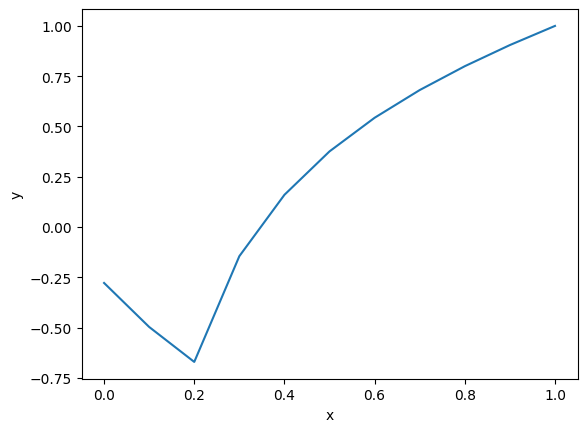

In [ ]:
U = RK_4_backward(p1, f)
print(U)
y = U[:,0]
# print(y)
# print(x)

plt.plot(x[::-1], y[::-1])
plt.xlabel("x")
plt.ylabel("y")
plt.show()
